## Local Inference on GPU
Model page: https://huggingface.co/nvidia/diar_sortformer_4spk-v1

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/nvidia/diar_sortformer_4spk-v1)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
!pip install nemo_toolkit['asr']
!pip install pydub

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
audio_path = "/content/drive/MyDrive/Thien/thien3di/Bedtime story/【BEDTIME STORY】 Truyện cổ tích Andersen 【 3Di VTuber Project ｜ Thiên】.wav"

In [ ]:
from nemo.collections.asr.models import SortformerEncLabelModel

diar_model = SortformerEncLabelModel.from_pretrained("nvidia/diar_streaming_sortformer_4spk-v2.1")
diar_model.eval()
predicted_segments = diar_model.diarize(audio=[audio_path], batch_size=4)


[NeMo W 2026-03-15 10:03:47 modelPT:188] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: null
    sample_rate: 16000
    num_spks: 4
    session_len_sec: 90
    soft_label_thres: 0.5
    soft_targets: false
    labels: null
    batch_size: 4
    shuffle: true
    num_workers: 18
    validation_mode: false
    use_lhotse: false
    use_bucketing: false
    pin_memory: true
    window_stride: 0.01
    subsampling_factor: 8
    
[NeMo W 2026-03-15 10:03:47 modelPT:195] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validation config : 
    manifest_filepath: null
    is_tarred: false
    tarred_audio_filepaths: null
    sample_rate: 16000
    num_spks: 4
    sess

[NeMo I 2026-03-15 10:03:49 save_restore_connector:285] Model SortformerEncLabelModel was successfully restored from /root/.cache/huggingface/hub/models--nvidia--diar_streaming_sortformer_4spk-v2.1/snapshots/fafaab5faa1617a0ca52d38dd3dc4bd636800d3d/diar_streaming_sortformer_4spk-v2.1.nemo.
[NeMo I 2026-03-15 10:03:49 vad_utils:81] No postprocessing YAML file has been provided. Default postprocessing configurations will be applied.


[NeMo W 2026-03-15 10:03:49 dataloader:826] The following configuration keys are ignored by Lhotse dataloader: soft_label_thres,session_len_sec,num_spks
Diarizing: 0it [00:00, ?it/s][NeMo W 2026-03-15 10:03:49 audio_to_diar_label_lhotse:67] Multiple channels detected in cut '【BEDTIME STORY】 Truyện cổ tích Andersen 【 3Di VTuber Project ｜ Thiên】' (2 channels). Only the first channel will be used; remaining channels are ignored.

Streaming Steps: 100%|██████████| 390/390 [00:23<00:00, 16.30it/s]
Diarizing: 1it [01:01, 61.47s/it]


In [ ]:
print(predicted_segments)

[['146.720 148.160 speaker_0', '150.320 151.520 speaker_0', '152.240 153.680 speaker_0', '156.160 158.160 speaker_0', '158.720 166.640 speaker_0', '175.600 186.240 speaker_0', '188.240 193.600 speaker_0', '194.880 195.200 speaker_0', '195.280 195.360 speaker_0', '196.160 204.800 speaker_0', '207.280 224.080 speaker_0', '226.240 226.800 speaker_0', '228.080 246.720 speaker_0', '247.440 277.200 speaker_0', '279.600 286.640 speaker_0', '301.760 308.160 speaker_0', '309.440 338.400 speaker_0', '360.960 370.320 speaker_0', '407.200 411.440 speaker_0', '544.160 551.520 speaker_0', '566.640 568.480 speaker_0', '1923.520 1923.760 speaker_0', '2032.720 2035.360 speaker_0', '2035.440 2035.600 speaker_0', '2035.760 2036.880 speaker_0', '2037.280 2038.160 speaker_0', '2044.400 2046.480 speaker_0', '2048.800 2055.520 speaker_0', '2211.760 2214.160 speaker_0', '2368.640 2368.960 speaker_0', '2815.520 2820.320 speaker_0', '2911.280 2911.440 speaker_0', '2917.760 2918.960 speaker_0', '2974.160 2977.92

In [ ]:
from pydub import AudioSegment
from IPython.display import Audio, display
import pandas as pd

# Load the original audio file

# full_audio = AudioSegment.from_wav(audio_path)
full_audio = AudioSegment.from_wav(audio_path)

# Process predicted_segments into a DataFrame
data = []
if predicted_segments and isinstance(predicted_segments[0], list):
    # Flatten the list of lists if necessary
    flat_predicted_segments = [item for sublist in predicted_segments for item in sublist]
else:
    flat_predicted_segments = predicted_segments

for segment_str in flat_predicted_segments:
    parts = segment_str.split()
    if len(parts) == 3:
        start_time = float(parts[0])
        end_time = float(parts[1])
        speaker = parts[2]
        data.append({'Start Time': start_time, 'End Time': end_time, 'Speaker': speaker})

df_segments = pd.DataFrame(data)
df_segments_sorted = df_segments.sort_values(by='Start Time').reset_index(drop=True)

print("Playing diarized audio segments grouped by speaker:")

# Group segments by speaker
for speaker, speaker_df in df_segments_sorted.groupby('Speaker'):
    print(f"\nPlaying segments for {speaker}:")
    # Sort segments by start time within each speaker group
    speaker_df_sorted = speaker_df.sort_values(by='Start Time').reset_index(drop=True)

    for index, row in speaker_df_sorted.iterrows():
        start_time_s = row['Start Time']
        end_time_s = row['End Time']
        # Speaker is already known from the groupby key

        start_time_ms = int(start_time_s * 1000)
        end_time_ms = int(end_time_s * 1000)

        # Extract segment
        audio_segment = full_audio[start_time_ms:end_time_ms]

        print(f"  Segment {index+1}: Start={start_time_s:.2f}s, End={end_time_s:.2f}s")
        display(Audio(audio_segment.export(format="wav").read(), rate=full_audio.frame_rate))

In [67]:
import nemo.collections.asr as nemo_asr
import torch
import torchaudio
import os

# Load model
asr_model = nemo_asr.models.ASRModel.from_pretrained("nvidia/parakeet-ctc-0.6b-vi")

# Load audio
audio_path = "download (3).wav"
waveform, sample_rate = torchaudio.load(audio_path)

# Downmix to mono nếu stereo
if waveform.shape[0] > 1:
    waveform = torch.mean(waveform, dim=0, keepdim=True)  # [1, time]

# Resample to 16kHz
target_sr = 16000
if sample_rate != target_sr:
    resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=target_sr)
    waveform = resampler(waveform)

# Save tạm file mono
mono_path = "temp_mono_16k.wav"
torchaudio.save(mono_path, waveform, target_sr)

# Transcribe với timestamps (trả về list[Hypothesis])
transcriptions = asr_model.transcribe([mono_path], timestamps=True)

# Lấy best hypothesis (thường là [0])
hyp = transcriptions[0]

# In text chính
print("Transcription:", hyp.text)

# In overall score (log-prob của hypothesis - càng gần 0 càng tự tin)
print(f"Overall Hypothesis Score: {hyp.score.item():.4f} (log-prob, higher/less negative = better confidence)")

# In confidence nếu có (thường None ở CTC Parakeet, nhưng check để an toàn)
if hyp.token_confidence is not None:
    print("\nToken-level confidence (per token):")
    for i, conf in enumerate(hyp.token_confidence):
        print(f"Token {i}: {conf:.4f}")

if hyp.word_confidence is not None:
    print("\nWord-level confidence:")
    # word_confidence thường là list[float] khớp với số từ trong hyp.text.split()
    words = hyp.text.split()
    for word, conf in zip(words, hyp.word_confidence):
        print(f"{word}: {conf:.4f}")

if hyp.frame_confidence is not None:
    print("\nFrame-level confidence (per audio frame):")
    print(hyp.frame_confidence)  # list[float] dài theo số frame

# In timestamps (word/segment/char)
if hyp.timestamp:
    print("\n=== Word-level timestamps ===")
    for stamp in hyp.timestamp.get('word', []):
        start = stamp.get('start', stamp.get('from', 0.0))
        end = stamp.get('end', stamp.get('to', 0.0))
        word = stamp.get('word', stamp.get('text', ''))
        print(f"{start:.2f}s - {end:.2f}s: {word}")

    print("\n=== Segment-level (câu) ===")
    for stamp in hyp.timestamp.get('segment', []):
        start = stamp.get('start', 0.0)
        end = stamp.get('end', 0.0)
        segment = stamp.get('segment', stamp.get('text', ''))
        print(f"{start:.2f}s - {end:.2f}s: {segment}")

    print("\n=== Char-level timestamps (nếu cần) ===")
    for stamp in hyp.timestamp.get('char', []):
        start = stamp.get('start', 0.0)
        end = stamp.get('end', 0.0)
        char = stamp.get('char', stamp.get('text', ''))
        print(f"{start:.2f}s - {end:.2f}s: {char}")
else:
    print("\nKhông có timestamps.")

# Xóa file tạm
os.remove(mono_path)

[NeMo I 2026-03-15 10:38:27 mixins:184] Tokenizer SentencePieceTokenizer initialized with 1024 tokens


[NeMo W 2026-03-15 10:38:27 modelPT:188] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath:
    - - /datasets/vlsp2020-vinai/tar_files/vlsp2020_tarred_audio_manifest_multitexts_v2_qwen_norm.json
    - - /datasets/VietMed/labeled_medical_data/tar_files/VietMed_tarred_audio_manifest_multitexts_v2_qwen_norm.json
    - - /datasets/FOSD/tar_files/FOSD_tarred_audio_manifest_fixed_wav_multitexts_v2_qwen_norm.json
    - - /datasets/LSVSC/tar_files/LSVSC_tarred_audio_manifest_multitexts_v2_qwen_norm.json
    - - /datasets/VSV-1100/tar_files/VSV1100_tarred_audio_manifest_multitexts_v2_qwen_norm.json
    - - /datasets/cv-corpus-20.0-2024-12-06/vi/tar_files/CV_tarred_audio_manifest_fixed_wav_multitexts_v2_qwen_norm.json
    - - /datasets/fleurs/data/vi_vn/tar_files/fleurs_tarred_audio_manifest_multitexts_v2_qwen_norm.json
    - - /datasets

[NeMo I 2026-03-15 10:38:32 save_restore_connector:285] Model EncDecCTCModelBPE was successfully restored from /root/.cache/huggingface/hub/models--nvidia--parakeet-ctc-0.6b-vi/snapshots/b0493142b49458810324e3db8be9e8e07b4ebc17/parakeet-ctc-0.6b-vi.nemo.
[NeMo I 2026-03-15 10:38:32 ctc_models:167] Timestamps requested, setting decoding timestamps to True. Capture them in Hypothesis object,                         with output[idx].timestep['word'/'segment'/'char']


[NeMo W 2026-03-15 10:38:33 dataloader:826] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-03-15 10:38:33 dataloader:523] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)
Transcribing: 1it [00:00,  7.32it/s]

Transcription: Tiêu tiêu sời soái quá đẹp, trai ầm cảm ơn, cảm ơná, không không ngờ là lại được hưởng ứng đấy, tưởng mọi người sẽ bảo tôiở hơi, nhưng mà thôi, không sao? Bạn ba ơi, bạn đẹp trai quá.
Overall Hypothesis Score: -20.4331 (log-prob, higher/less negative = better confidence)

=== Word-level timestamps ===
0.00s - 0.24s: Tiêu
0.24s - 0.48s: tiêu
0.48s - 0.80s: sời
0.80s - 1.12s: soái
1.12s - 1.36s: quá
1.36s - 1.52s: đẹp ,
1.76s - 1.92s: trai
1.92s - 2.24s: ầm
2.24s - 2.56s: cảm
2.56s - 2.80s: ơn ,
2.88s - 3.12s: cảm
3.12s - 3.60s: ơná ,
4.00s - 4.16s: không
4.16s - 4.40s: không
4.40s - 4.64s: ngờ
4.64s - 4.80s: là
4.80s - 4.88s: lại
4.88s - 5.12s: được
5.12s - 5.28s: hưởng
5.28s - 5.44s: ứng
5.44s - 5.68s: đấy ,
5.76s - 6.00s: tưởng
6.00s - 6.16s: mọi
6.16s - 6.24s: người
6.24s - 6.48s: sẽ
6.48s - 6.64s: bảo
6.64s - 6.96s: tôiở
6.96s - 7.12s: hơi ,
7.20s - 7.28s: nhưng
7.28s - 7.44s: mà
7.44s - 7.52s: thôi ,
7.68s - 7.84s: không
7.84s - 8.00s: sao ?
8.24s - 8.40s: Bạn
8.40s 

In [60]:
print(transcriptions)

[Hypothesis(score=tensor(-3.0088), y_sequence=tensor([  53,  359, 1024,   17,  958, 1024,   17,  151, 1024, 1024,  856, 1024,
        1024,  188, 1024, 1024, 1024,  212, 1024, 1024, 1024, 1024, 1024, 1024,
        1024, 1024, 1024,  248, 1024,    9,   57, 1024, 1024, 1024, 1024,   16,
        1024, 1024,  248, 1024, 1024,  708, 1024,   16, 1024,  248, 1024,   14,
         898,  877, 1024, 1024, 1024, 1024,   39, 1024,  124, 1024,  248,  248,
        1024,  513, 1024,  322, 1024,    6]), text='Cậu nhẹ nhàng hồi nào vậy ngày mai, ngày kia, ngày kìa không phải ngày hôm nay.', dec_out=None, dec_state=None, timestamp=[], alignments=None, frame_confidence=None, token_confidence=None, word_confidence=None, length=0, y=None, lm_state=None, lm_scores=None, ngram_lm_state=None, tokens=None, last_token=None, token_duration=None, last_frame=None, biasing_cfg=None, xatt_scores=None)]


In [ ]:
import pandas as pd
import numpy as np

# Assuming full_audio and df_segments_sorted are available from previous steps
# If full_audio is not defined, use a placeholder. Assuming it's defined.
# If not, you might need to re-run the cell where full_audio is loaded.

# 1. Total Audio Duration
total_audio_duration = full_audio.duration_seconds # in seconds

# 2. Total Speaking Time per Speaker (includes overlaps with other speakers)
speaker_total_times = df_segments_sorted.groupby('Speaker')['End Time'].sum() - df_segments_sorted.groupby('Speaker')['Start Time'].sum()
speaker_total_times = speaker_total_times.rename('Total Speaking Time (s)')

# 3. Calculate Total Overlapping Speech Duration
events = []
for _, row in df_segments_sorted.iterrows():
    events.append((row['Start Time'], 1))
    events.append((row['End Time'], -1))

events.sort(key=lambda x: x[0])

active_speakers = 0
last_time = 0
total_overlapping_speech_duration = 0
total_unique_speech_duration = 0 # Time when at least one speaker is active

for time, type in events:
    duration = time - last_time
    if duration > 0:
        if active_speakers > 1:
            total_overlapping_speech_duration += duration
        if active_speakers > 0:
            total_unique_speech_duration += duration

    active_speakers += type
    last_time = time

# 4. Calculate Total Silence Duration
total_speech_in_audio = total_unique_speech_duration
total_silence_duration = total_audio_duration - total_speech_in_audio


print("--- Diarization Statistics ---")
print(f"Total Audio Duration: {total_audio_duration:.2f} seconds")
print("\nTotal Speaking Time per Speaker (includes overlaps with other speakers):")
display(speaker_total_times.to_frame())
print(f"\nTotal Overlapping Speech Duration: {total_overlapping_speech_duration:.2f} seconds")
print(f"Total Unique Speech Duration (any speaker): {total_unique_speech_duration:.2f} seconds")
print(f"Total Silence Duration: {total_silence_duration:.2f} seconds")

--- Diarization Statistics ---
Total Audio Duration: 1223.95 seconds

Total Speaking Time per Speaker (includes overlaps with other speakers):


,Total Speaking Time (s)
Speaker,
speaker_0,656.24



Total Overlapping Speech Duration: 0.00 seconds
Total Unique Speech Duration (any speaker): 656.24 seconds
Total Silence Duration: 567.71 seconds


### Explanation of Statistics:

*   **Total Audio Duration**: The entire length of the provided audio file.
*   **Total Speaking Time per Speaker**: This is the sum of all segments assigned to each speaker. Note that if two speakers talk at the same time, both their individual 'Total Speaking Time' will increase for that overlapping period.
*   **Total Overlapping Speech Duration**: The total amount of time during the audio where two or more speakers were speaking simultaneously.
*   **Total Unique Speech Duration (any speaker)**: The total time during the audio where at least one speaker was active, without double-counting periods of overlap. This represents the actual duration of spoken content.
*   **Total Silence Duration**: The total time in the audio where no speaker was detected.

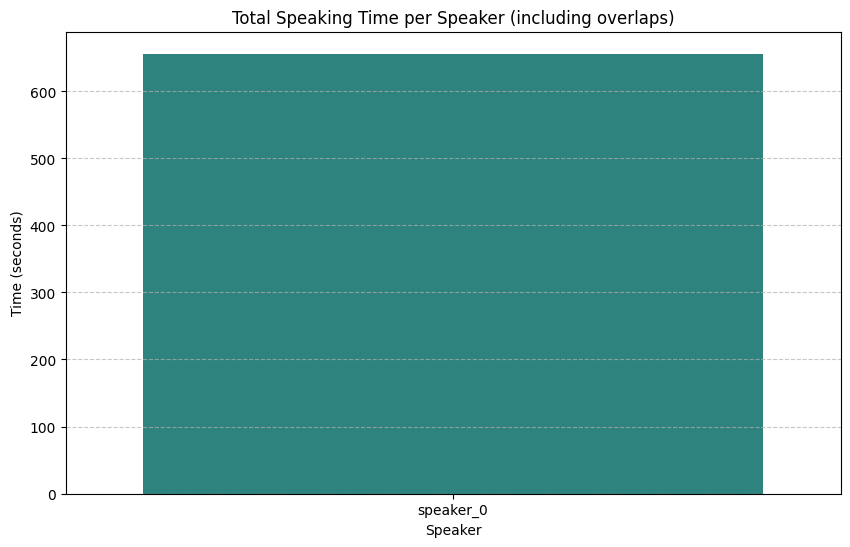

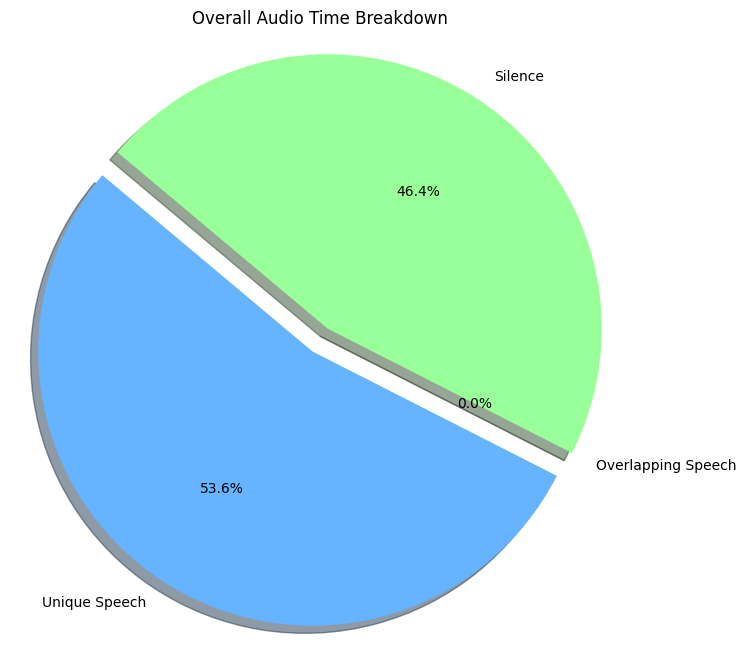

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Total Speaking Time per Speaker
plt.figure(figsize=(10, 6))
sns.barplot(x=speaker_total_times.index, y=speaker_total_times.values, palette='viridis')
plt.title('Total Speaking Time per Speaker (including overlaps)')
plt.xlabel('Speaker')
plt.ylabel('Time (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot Overall Audio Breakdown (Unique Speech, Overlap, Silence)
labels = ['Unique Speech', 'Overlapping Speech', 'Silence']
sizes = [total_unique_speech_duration - total_overlapping_speech_duration, total_overlapping_speech_duration, total_silence_duration]
colors = ['#66b3ff','#ffcc99','#99ff99'] # Light blue, light orange, light green
explode = (0.1, 0, 0)  # Explode the 'Overlapping Speech' slice

# Ensure sizes are non-negative, if a segment duration is very small or negative due to rounding or edge cases.
sizes = [max(0, s) for s in sizes]

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Overall Audio Time Breakdown')
plt.show()